Regiones y fronteras

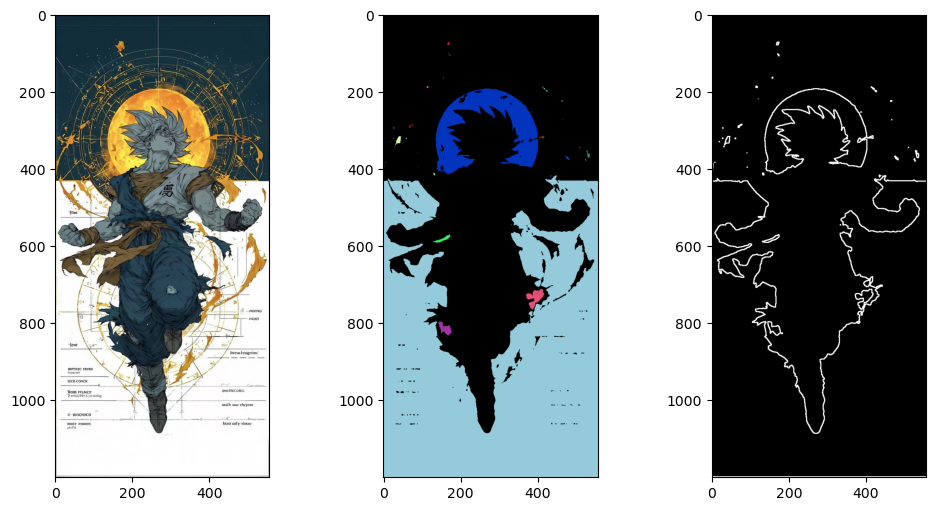

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('goku.jpg')
gray =cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
#combino tecnicas
blur=cv2.GaussianBlur(gray,(7,7),0)
_,binary=cv2.threshold(blur,100,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
#encontramos las regiones
num_l,labels=cv2.connectedComponents(binary)
#identificamos por colores
colors=np.random.randint(0,255,size=(num_l,3),dtype=np.uint8)
#fondo negro
colors[0] = [0, 0, 0]
colorear = colors[labels]
#encontrar fronteras
contornos,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contorno_fin=cv2.drawContours(np.zeros_like(gray),contornos,-1,255,2)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.imshow(colorear)
plt.subplot(1,3,3)
plt.imshow(contorno_fin,cmap='gray')
plt.show()


CONTEO

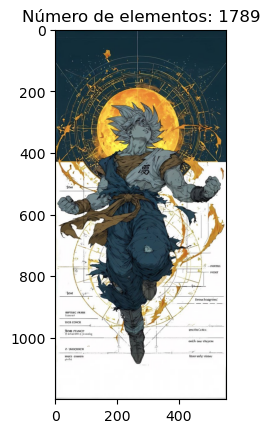

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img=measure.label(binary, connectivity=2) # 2- conectividad es de 4 1- conectividad es de 8
    num_obj=np.max(e_img)
    return num_obj
imagen=cv2.imread('goku.jpg')
conteo=contar_elementos(imagen)

plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f'Número de elementos: {conteo}')
plt.show()


Region 1: RGB(95,179,61) - 40 pixeles
Region 2: RGB(234,203,92) - 12 pixeles
Region 3: RGB(3,98,243) - 8 pixeles
Region 4: RGB(14,149,245) - 20 pixeles
Region 5: RGB(46,106,244) - 22 pixeles
Region 6: RGB(99,187,71) - 25337 pixeles
Region 7: RGB(212,153,199) - 14 pixeles
Region 8: RGB(188,174,65) - 1 pixeles
Region 9: RGB(153,20,44) - 11 pixeles
Region 10: RGB(203,152,102) - 4 pixeles
Region 11: RGB(214,240,39) - 3 pixeles
Region 12: RGB(121,24,34) - 36 pixeles
Region 13: RGB(114,210,65) - 6 pixeles
Region 14: RGB(239,39,214) - 65 pixeles
Region 15: RGB(244,151,25) - 178 pixeles
Region 16: RGB(74,145,222) - 4 pixeles
Region 17: RGB(14,202,85) - 7 pixeles
Region 18: RGB(145,117,87) - 4 pixeles
Region 19: RGB(184,189,221) - 5 pixeles
Region 20: RGB(116,237,109) - 3 pixeles
Region 21: RGB(85,99,172) - 90 pixeles
Region 22: RGB(226,153,103) - 2 pixeles
Region 23: RGB(235,146,36) - 38 pixeles
Region 24: RGB(151,62,68) - 13 pixeles
Region 25: RGB(181,130,160) - 3 pixeles
Region 26: RGB(160,1

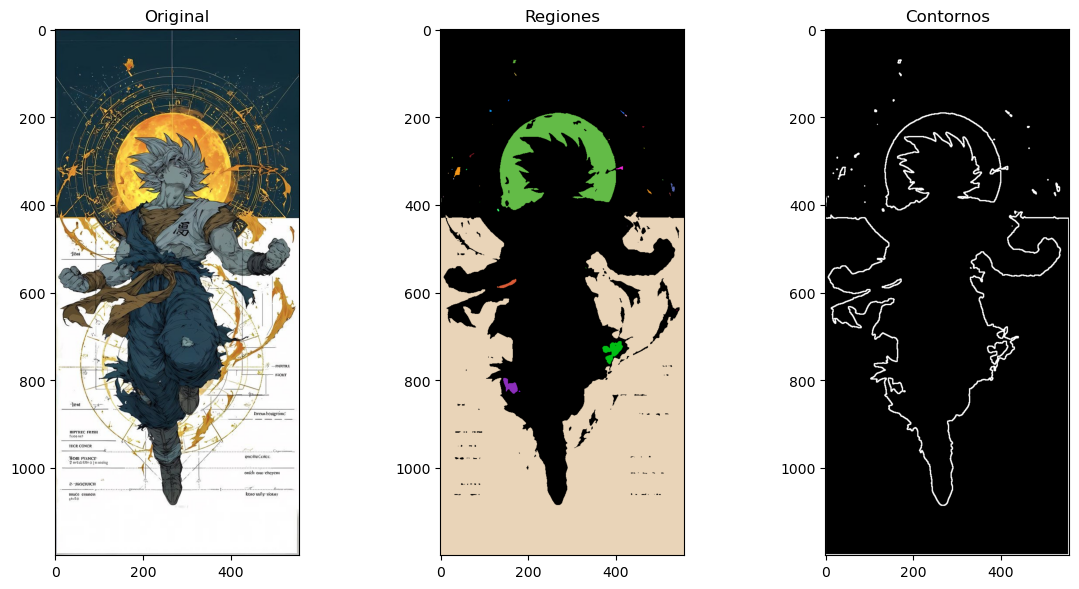

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('goku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

num_l, labels = cv2.connectedComponents(binary)
np.random.seed(42)
colors = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]
colorear = colors[labels]

contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

total = np.max(measure.label(binary, connectivity=2))

for i in range(1, num_l):
    r, g, b = int(colors[i][0]), int(colors[i][1]), int(colors[i][2])
    pixeles = int(np.sum(labels == i))
    print(f"Region {i}: RGB({r},{g},{b}) - {pixeles} pixeles")

print(f"\nTotal de elementos: {total}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(colorear), plt.title('Regiones')
plt.subplot(1, 3, 3), plt.imshow(contorno_fin, cmap='gray'), plt.title('Contornos')
plt.tight_layout()
plt.show()